# 01 17.1 B&C NL Cleaning Walkthrough

This notebook walks through the cleaning of ENTSO-E `17.1 B&C` for the NL control area:

- starting from the raw zip archives in `data/00_Raw/ENTSOE/17_1_BC_NL_IR`
- transforming the XML payloads into a readable native long table
- running diagnostics on duplicates, time periods, granularities, and missingness
- explaining the main anomaly in the 2025 raw files
- cleaning the dataset step by step into hourly long and hourly wide outputs

The main structural finding is important:

- the raw files behave like **daily contracted reserve periods**
- from 2025 onward the XML reports `resolution = PT15M`
- but each direction still contains only **one point for the whole delivery day**

So the notebook explicitly checks that inconsistency before applying the cleaning rule.


In [1]:
from __future__ import annotations

import importlib.util
import json
import sys
import zipfile
from pathlib import Path

import pandas as pd
from IPython import get_ipython
from IPython.display import Markdown, display

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 220)
pd.set_option("display.expand_frame_repr", False)
plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root.")


def load_cleaning_module(repo_root: Path):
    module_path = repo_root / "scripts" / "Data" / "01_cleaning" / "balancing_reserves_under_contract_pipeline.py"
    spec = importlib.util.spec_from_file_location("balancing_reserves_cleaning_notebook", module_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
    return module


REPO_ROOT = find_repo_root()
cleaning = load_cleaning_module(REPO_ROOT)


In [2]:
RAW_DIR = REPO_ROOT / "data" / "00_Raw" / "ENTSOE" / "17_1_BC_NL_IR"
OUTPUT_DIR = REPO_ROOT / "data" / "01_cleaned" / "Balancing" / "balancing_reserves_under_contract"
PARSED_OUTPUT = OUTPUT_DIR / "parsed" / "balancing_reserves_under_contract_long.csv"
HOURLY_LONG_OUTPUT = OUTPUT_DIR / "hourly" / "balancing_reserves_under_contract_hourly_long.csv"
HOURLY_WIDE_OUTPUT = OUTPUT_DIR / "hourly" / "balancing_reserves_under_contract_hourly_wide.csv"
DIAGNOSTICS_DIR = OUTPUT_DIR / "diagnostics"

config_df = pd.DataFrame(
    [
        {"setting": "Raw input directory", "value": str(RAW_DIR)},
        {"setting": "Cleaned output directory", "value": str(OUTPUT_DIR)},
        {"setting": "Market", "value": cleaning.MARKET},
        {"setting": "Reporting timezone", "value": cleaning.MARKET_TIMEZONE},
        {"setting": "Known-at rule", "value": cleaning.KNOWN_AT_RULE},
    ]
)
display(config_df)


,setting,value
0,Raw input directory,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\ENTSOE\17_1_BC_NL_IR
1,Cleaned output directory,C:\Users\marijnvalk\PycharmProjects\Thesis\data\01_cleaned\Balancing\balancing_reserves_under_contract
2,Market,NL
3,Reporting timezone,Europe/Amsterdam
4,Known-at rule,allocation_decision_datetime_utc


## 1. Raw Archive Inventory

Before parsing any XML payload, inspect the archive structure. This tells us how many zip files exist, how many XML members sit inside each archive, and whether some files are clearly page splits rather than one-file-per-year snapshots.


,archive,size_kb,xml_member_count
0,17_1_bc_nl_ir_2022_offset_0000.zip,2.7,1
1,17_1_bc_nl_ir_2022_offset_0100.zip,2.7,1
2,17_1_bc_nl_ir_2022_offset_0200.zip,2.7,1
3,17_1_bc_nl_ir_2022_offset_0300.zip,2.7,1
4,17_1_bc_nl_ir_2022_offset_0400.zip,2.6,1
5,17_1_bc_nl_ir_2022_offset_0500.zip,2.7,1
6,17_1_bc_nl_ir_2022_offset_0600.zip,2.6,1
7,17_1_bc_nl_ir_2022_offset_0700.zip,1.6,1
8,17_1_bc_nl_ir_2023_offset_0000.zip,2.6,1
9,17_1_bc_nl_ir_2023_offset_0100.zip,2.7,1


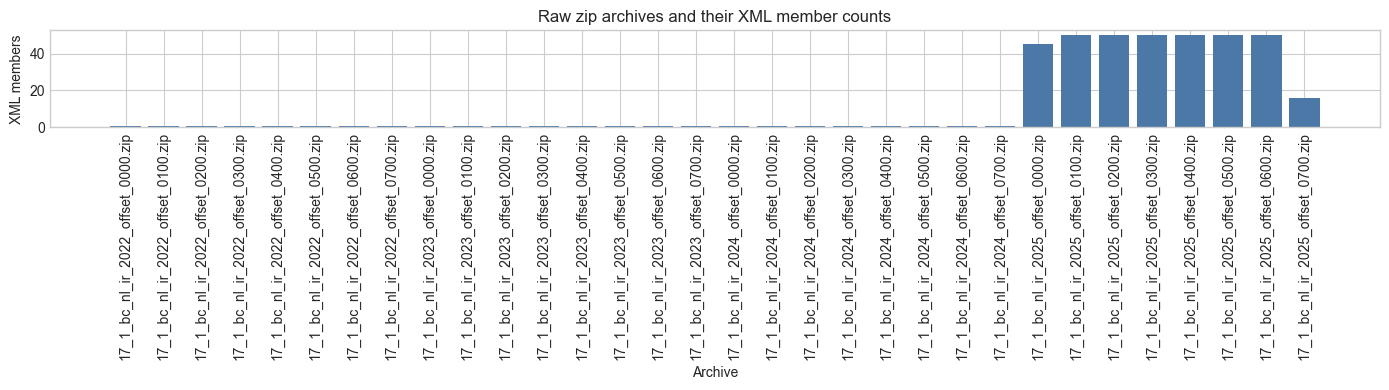

In [3]:
archive_rows = []
for archive_path in sorted(RAW_DIR.glob("*.zip")):
    with zipfile.ZipFile(archive_path) as zf:
        xml_members = [name for name in zf.namelist() if name.lower().endswith(".xml")]
    archive_rows.append(
        {
            "archive": archive_path.name,
            "size_kb": round(archive_path.stat().st_size / 1024, 1),
            "xml_member_count": len(xml_members),
        }
    )

archive_inventory_df = pd.DataFrame(archive_rows)
display(archive_inventory_df)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(archive_inventory_df["archive"], archive_inventory_df["xml_member_count"], color="#4C78A8")
ax.set_title("Raw zip archives and their XML member counts")
ax.set_ylabel("XML members")
ax.set_xlabel("Archive")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 2. Inspect One Raw XML Member

The first useful cleaning step is to make the raw payload readable. We inspect one XML member directly so the document structure is visible before it gets flattened into tables.


In [4]:
sample_archive = sorted(RAW_DIR.glob("*.zip"))[-1]
with zipfile.ZipFile(sample_archive) as zf:
    sample_member = sorted(name for name in zf.namelist() if name.lower().endswith(".xml"))[0]
    sample_xml_text = zf.read(sample_member).decode("utf-8", errors="replace")

print("Archive:", sample_archive.name)
print("Member:", sample_member)
print()
print("\n".join(sample_xml_text.splitlines()[:40]))


Archive: 17_1_bc_nl_ir_2025_offset_0700.zip
Member: 001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202512272300-202512282300.xml

<?xml version="1.0" encoding="UTF-8"?>
<Balancing_MarketDocument xmlns="urn:iec62325.351:tc57wg16:451-6:balancingdocument:4:4">
    <mRID>2a0fae85f9124431adbff3a25941ad97</mRID>
    <revisionNumber>1</revisionNumber>
    <type>A81</type>
    <process.processType>A47</process.processType>
    <sender_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</sender_MarketParticipant.mRID>
    <sender_MarketParticipant.marketRole.type>A32</sender_MarketParticipant.marketRole.type>
    <receiver_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</receiver_MarketParticipant.mRID>
    <receiver_MarketParticipant.marketRole.type>A33</receiver_MarketParticipant.marketRole.type>
    <createdDateTime>2026-03-25T14:16:24Z</createdDateTime>
    <area_Domain.mRID codingScheme="A01">10YNL----------L</area_Domain.mRID>
    <allocationDecision_

## 3. Parse the Raw Files Into a Readable Native Table

The shared cleaning module parses every zip member and keeps the native contract intervals before any hourly expansion.


In [5]:
raw_parsed, member_summary_df, archive_summary_df, parse_errors_df = cleaning.parse_archives(RAW_DIR)

print(f"Raw parsed rows: {len(raw_parsed):,}")
print(f"Member summaries: {len(member_summary_df):,}")
print(f"Archive summaries: {len(archive_summary_df):,}")
print(f"Parse errors: {len(parse_errors_df):,}")

if not parse_errors_df.empty:
    display(parse_errors_df.head())


Raw parsed rows: 2,930
Member summaries: 385
Archive summaries: 32
Parse errors: 0


In [6]:
readable_native = (
    raw_parsed[
        [
            "timestamp_utc",
            "interval_end_utc",
            "effective_interval_minutes",
            "quantity_maw",
            "procurement_price_eur",
            "flow_direction_label",
            "contract_type_label",
            "reserve_source_label",
            "price_category_label",
            "reported_resolution",
            "point_count_in_period",
            "expected_point_count_from_reported_resolution",
            "allocation_decision_datetime_utc",
            "source_archive",
            "source_member",
        ]
    ]
    .sort_values(["timestamp_utc", "flow_direction_label"])
    .reset_index(drop=True)
)

display(readable_native.head(12))


,timestamp_utc,interval_end_utc,effective_interval_minutes,quantity_maw,procurement_price_eur,flow_direction_label,contract_type_label,reserve_source_label,price_category_label,reported_resolution,point_count_in_period,expected_point_count_from_reported_resolution,allocation_decision_datetime_utc,source_archive,source_member
0,2021-12-31 23:00:00+00:00,2022-01-01 23:00:00+00:00,1440,800.0,11.75,Down,Daily,Local,Average_bid_price,P1D,1,1,NaT,17_1_bc_nl_ir_2022_offset_0000.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202112312300-202202192300.xml
1,2021-12-31 23:00:00+00:00,2022-01-01 23:00:00+00:00,1440,915.0,4.71,Up,Daily,Local,Average_bid_price,P1D,1,1,NaT,17_1_bc_nl_ir_2022_offset_0000.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202112312300-202202192300.xml
2,2022-01-01 23:00:00+00:00,2022-01-02 23:00:00+00:00,1440,745.0,13.85,Down,Daily,Local,Average_bid_price,P1D,1,1,NaT,17_1_bc_nl_ir_2022_offset_0000.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202112312300-202202192300.xml
3,2022-01-01 23:00:00+00:00,2022-01-02 23:00:00+00:00,1440,995.0,3.62,Up,Daily,Local,Average_bid_price,P1D,1,1,NaT,17_1_bc_nl_ir_2022_offset_0000.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202112312300-202202192300.xml
4,2022-01-02 23:00:00+00:00,2022-01-03 23:00:00+00:00,1440,740.0,7.86,Down,Daily,Local,Average_bid_price,P1D,1,1,NaT,17_1_bc_nl_ir_2022_offset_0000.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202112312300-202202192300.xml
5,2022-01-02 23:00:00+00:00,2022-01-03 23:00:00+00:00,1440,995.0,3.17,Up,Daily,Local,Average_bid_price,P1D,1,1,NaT,17_1_bc_nl_ir_2022_offset_0000.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202112312300-202202192300.xml
6,2022-01-03 23:00:00+00:00,2022-01-04 23:00:00+00:00,1440,835.0,4.88,Down,Daily,Local,Average_bid_price,P1D,1,1,NaT,17_1_bc_nl_ir_2022_offset_0000.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202112312300-202202192300.xml
7,2022-01-03 23:00:00+00:00,2022-01-04 23:00:00+00:00,1440,995.0,2.83,Up,Daily,Local,Average_bid_price,P1D,1,1,NaT,17_1_bc_nl_ir_2022_offset_0000.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202112312300-202202192300.xml
8,2022-01-04 23:00:00+00:00,2022-01-05 23:00:00+00:00,1440,645.0,5.73,Down,Daily,Local,Average_bid_price,P1D,1,1,NaT,17_1_bc_nl_ir_2022_offset_0000.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202112312300-202202192300.xml
9,2022-01-04 23:00:00+00:00,2022-01-05 23:00:00+00:00,1440,795.0,2.46,Up,Daily,Local,Average_bid_price,P1D,1,1,NaT,17_1_bc_nl_ir_2022_offset_0000.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202112312300-202202192300.xml


## 4. Interpret the Native Dataset

These diagnostics answer the basic structural questions:

- which codes occur
- what time coverage we have
- what interval durations exist
- whether the source is really UTC


In [7]:
overview_df = pd.DataFrame(
    [
        {"metric": "Rows", "value": len(raw_parsed)},
        {"metric": "Min timestamp UTC", "value": raw_parsed["timestamp_utc"].min()},
        {"metric": "Max interval end UTC", "value": raw_parsed["interval_end_utc"].max()},
        {"metric": "Unique flow directions", "value": ", ".join(sorted(raw_parsed["flow_direction_label"].dropna().unique()))},
        {"metric": "Unique contract types", "value": ", ".join(sorted(raw_parsed["contract_type_label"].dropna().unique()))},
        {"metric": "Unique reserve sources", "value": ", ".join(sorted(raw_parsed["reserve_source_label"].dropna().unique()))},
        {"metric": "Unique price categories", "value": ", ".join(sorted(raw_parsed["price_category_label"].dropna().unique()))},
        {"metric": "Unique reported resolutions", "value": ", ".join(sorted(raw_parsed["reported_resolution"].dropna().unique()))},
    ]
)
display(overview_df)

code_tables_df = pd.concat(
    [
        pd.DataFrame(cleaning.FLOW_DIRECTION_LABELS.items(), columns=["code", "label"]).assign(code_family="flow_direction"),
        pd.DataFrame(cleaning.CONTRACT_TYPE_LABELS.items(), columns=["code", "label"]).assign(code_family="contract_type"),
        pd.DataFrame(cleaning.RESERVE_SOURCE_LABELS.items(), columns=["code", "label"]).assign(code_family="reserve_source"),
        pd.DataFrame(cleaning.PRICE_CATEGORY_LABELS.items(), columns=["code", "label"]).assign(code_family="price_category"),
    ],
    ignore_index=True,
)
display(code_tables_df)


,metric,value
0,Rows,2930
1,Min timestamp UTC,2021-12-31 23:00:00+00:00
2,Max interval end UTC,2026-01-01 23:00:00+00:00
3,Unique flow directions,"Down, Up"
4,Unique contract types,Daily
5,Unique reserve sources,Local
6,Unique price categories,Average_bid_price
7,Unique reported resolutions,"P1D, PT15M"


,code,label,code_family
0,A01,Up,flow_direction
1,A02,Down,flow_direction
2,A03,Symmetric,flow_direction
3,A01,Daily,contract_type
4,A02,Weekly,contract_type
5,A03,Monthly,contract_type
6,A04,Yearly,contract_type
7,A06,Long_term_contract,contract_type
8,A13,Hourly,contract_type
9,A01,Standard,reserve_source


,reported_resolution,point_count_in_period,expected_point_count_from_reported_resolution,rows
0,P1D,1,1,2198
1,PT15M,1,92,2
2,PT15M,1,96,716
3,PT15M,1,100,2


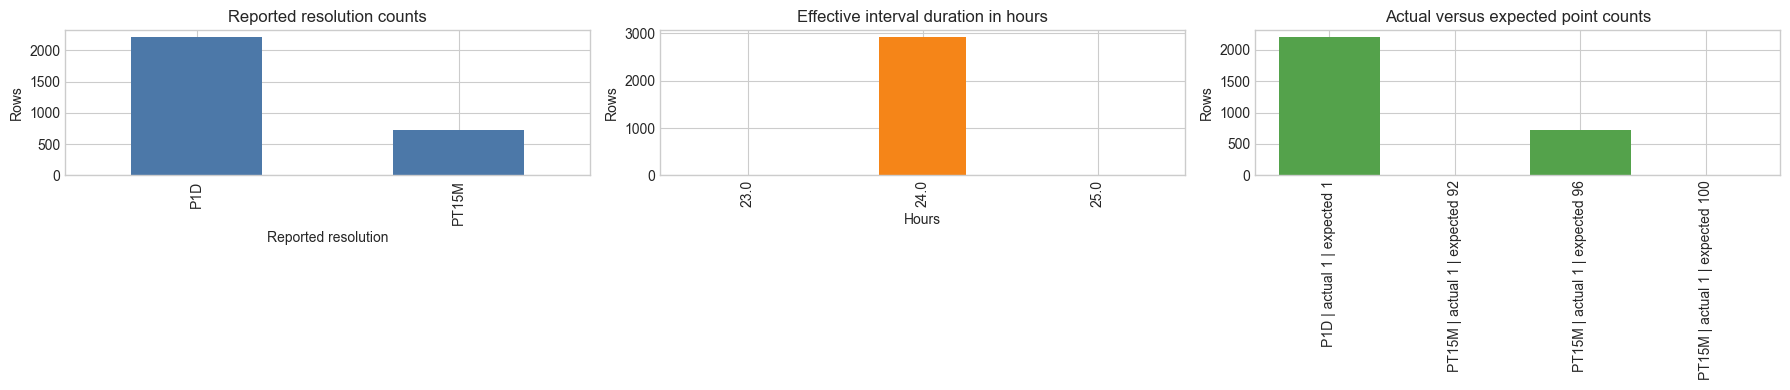

In [8]:
native_interval_hours = raw_parsed["effective_interval_minutes"] / 60.0
native_interval_distribution = native_interval_hours.value_counts().sort_index()
resolution_distribution = raw_parsed["reported_resolution"].value_counts().sort_index()
point_count_distribution = (
    raw_parsed.groupby(["reported_resolution", "point_count_in_period", "expected_point_count_from_reported_resolution"])
    .size()
    .reset_index(name="rows")
    .sort_values(["reported_resolution", "point_count_in_period"])
)

display(point_count_distribution)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
resolution_distribution.plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Reported resolution counts")
axes[0].set_xlabel("Reported resolution")
axes[0].set_ylabel("Rows")

native_interval_distribution.plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("Effective interval duration in hours")
axes[1].set_xlabel("Hours")
axes[1].set_ylabel("Rows")

point_count_distribution["label"] = (
    point_count_distribution["reported_resolution"].astype(str)
    + " | actual "
    + point_count_distribution["point_count_in_period"].astype(str)
    + " | expected "
    + point_count_distribution["expected_point_count_from_reported_resolution"].astype(str)
)
axes[2].bar(point_count_distribution["label"], point_count_distribution["rows"], color="#54A24B")
axes[2].set_title("Actual versus expected point counts")
axes[2].set_ylabel("Rows")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


,delivery_year,rows,rows_with_known_at,known_at_share
0,2022,730,0,0.000000
1,2023,732,0,0.000000
2,2024,734,0,0.000000
3,2025,732,718,0.980874
4,2026,2,2,1.000000


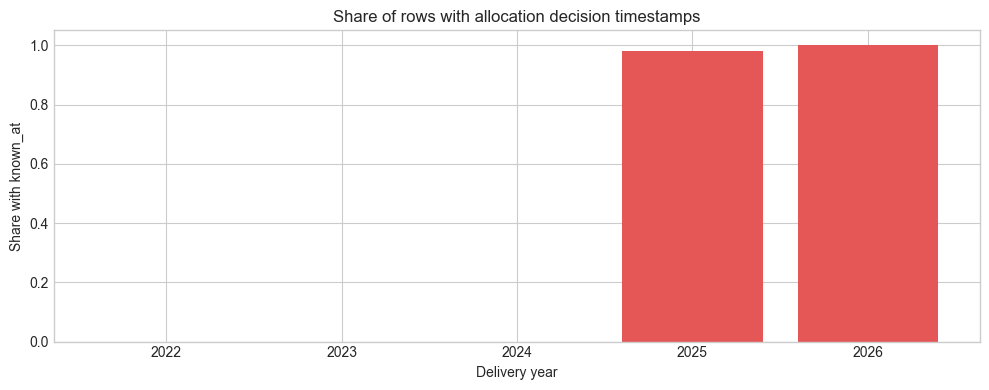

In [9]:
known_at_by_year = (
    raw_parsed.assign(delivery_year=pd.to_datetime(raw_parsed["target_delivery_local_date"]).dt.year)
    .groupby("delivery_year", as_index=False)
    .agg(
        rows=("timestamp_utc", "size"),
        rows_with_known_at=("allocation_decision_datetime_utc", lambda s: int(s.notna().sum())),
    )
)
known_at_by_year["known_at_share"] = known_at_by_year["rows_with_known_at"] / known_at_by_year["rows"]
display(known_at_by_year)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(known_at_by_year["delivery_year"].astype(str), known_at_by_year["known_at_share"], color="#E45756")
ax.set_title("Share of rows with allocation decision timestamps")
ax.set_xlabel("Delivery year")
ax.set_ylabel("Share with known_at")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 5. Spot Duplicates, Missing Days, and Time-Period Issues

The native daily contracts should yield one row per direction per delivery day. So we explicitly test:

- duplicate native intervals
- missing local delivery dates
- DST-driven 23/24/25-hour day lengths


In [10]:
deduped_native, duplicates_removed = cleaning.deduplicate_rows(raw_parsed)

duplicate_summary_df = pd.DataFrame(
    [
        {"metric": "Raw rows", "value": len(raw_parsed)},
        {"metric": "Rows after deduplication", "value": len(deduped_native)},
        {"metric": "Duplicate rows removed", "value": len(duplicates_removed)},
    ]
)
display(duplicate_summary_df)
display(duplicates_removed.head(10))


,metric,value
0,Raw rows,2930
1,Rows after deduplication,2924
2,Duplicate rows removed,6


,family,market,timestamp_utc,interval_end_utc,effective_interval_minutes,quantity_maw,procurement_price_eur,reported_resolution,reported_resolution_minutes,interval_interpretation,document_type,document_type_label,process_type,business_type,business_type_label,contract_type_code,contract_type_label,reserve_source_code,reserve_source_label,flow_direction_code,flow_direction_label,price_category_code,price_category_label,curve_type,area_domain,currency_unit,quantity_unit,created_datetime_utc,allocation_decision_datetime_utc,known_at_utc,known_at_rule,document_period_start_utc,document_period_end_utc,series_period_start_utc,series_period_end_utc,source_archive,source_member,source_path,timeseries_index,period_index,point_position,point_count_in_period,expected_point_count_from_reported_resolution,target_delivery_local_date,target_hour_local
0,balancing_reserves_under_contract,NL,2022-12-31 23:00:00+00:00,2023-01-01 23:00:00+00:00,1440,985.0,1.33,P1D,1440,single_point_full_period,A81,Contracted_reserves,A47,B95,Procured_capacity,A01,Daily,A04,Local,A01,Up,A06,Average_bid_price,A03,10YNL----------L,EUR,MAW,2026-03-25 14:12:16+00:00,NaT,NaT,allocation_decision_datetime_utc,2022-12-16 23:00:00+00:00,2023-01-01 23:00:00+00:00,2022-12-31 23:00:00+00:00,2023-01-01 23:00:00+00:00,17_1_bc_nl_ir_2022_offset_0700.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202212162300-202301012300.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\ENTSOE\17_1_BC_NL_IR\17_1_bc_nl_ir_2022_offset_0700.zip::001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202212162300-202301012300.xml,31,1,1,1,1,2023-01-01,0
1,balancing_reserves_under_contract,NL,2022-12-31 23:00:00+00:00,2023-01-01 23:00:00+00:00,1440,935.0,5.36,P1D,1440,single_point_full_period,A81,Contracted_reserves,A47,B95,Procured_capacity,A01,Daily,A04,Local,A02,Down,A06,Average_bid_price,A03,10YNL----------L,EUR,MAW,2026-03-25 14:12:16+00:00,NaT,NaT,allocation_decision_datetime_utc,2022-12-16 23:00:00+00:00,2023-01-01 23:00:00+00:00,2022-12-31 23:00:00+00:00,2023-01-01 23:00:00+00:00,17_1_bc_nl_ir_2022_offset_0700.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202212162300-202301012300.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\ENTSOE\17_1_BC_NL_IR\17_1_bc_nl_ir_2022_offset_0700.zip::001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202212162300-202301012300.xml,32,1,1,1,1,2023-01-01,0
2,balancing_reserves_under_contract,NL,2023-12-31 23:00:00+00:00,2024-01-01 23:00:00+00:00,1440,954.0,4.32,P1D,1440,single_point_full_period,A81,Contracted_reserves,A47,B95,Procured_capacity,A01,Daily,A04,Local,A01,Up,A06,Average_bid_price,A03,10YNL----------L,EUR,MAW,2026-03-25 14:13:47+00:00,NaT,NaT,allocation_decision_datetime_utc,2023-12-16 23:00:00+00:00,2024-01-01 23:00:00+00:00,2023-12-31 23:00:00+00:00,2024-01-01 23:00:00+00:00,17_1_bc_nl_ir_2023_offset_0700.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202312162300-202401012300.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\ENTSOE\17_1_BC_NL_IR\17_1_bc_nl_ir_2023_offset_0700.zip::001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202312162300-202401012300.xml,32,1,1,1,1,2024-01-01,0
3,balancing_reserves_under_contract,NL,2023-12-31 23:00:00+00:00,2024-01-01 23:00:00+00:00,1440,601.0,1.89,P1D,1440,single_point_full_period,A81,Contracted_reserves,A47,B95,Procured_capacity,A01,Daily,A04,Local,A02,Down,A06,Average_bid_price,A03,10YNL----------L,EUR,MAW,2026-03-25 14:13:47+00:00,NaT,NaT,allocation_decision_datetime_utc,2023-12-16 23:00:00+00:00,2024-01-01 23:00:00+00:00,2023-12-31 23:00:00+00:00,2024-01-01 23:00:00+00:00,17_1_bc_nl_ir_2023_offset_0700.zip,001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVES_UNDER_CONTRACT_R3_202312162300-202401012300.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\ENTSOE\17_1_BC_NL_IR\17_1_bc_nl_ir_2023_offset_0700.zip::001-AMOUNT_AND_PRICES_PAID_OF_BALANCING_RESERVE

,flow_direction,observed_delivery_days,unique_delivery_days,expected_delivery_days,missing_delivery_days,first_missing_delivery_days
0,Down,1462,1462,1462,0,
1,Up,1462,1462,1462,0,


,delivery_year,interval_hours,rows
0,2022,23.0,2
1,2022,24.0,726
2,2022,25.0,2
3,2023,23.0,2
4,2023,24.0,726
5,2023,25.0,2
6,2024,23.0,2
7,2024,24.0,728
8,2024,25.0,2
9,2025,23.0,2


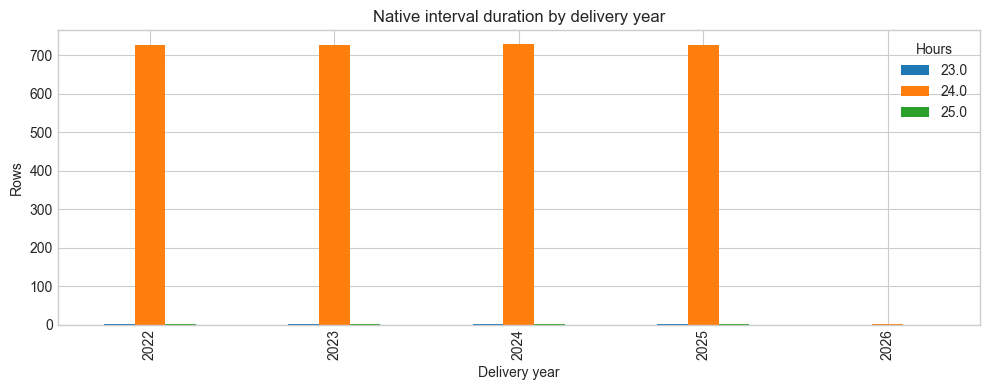

In [11]:
def native_delivery_grid_check(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for direction, group in frame.groupby("flow_direction_label"):
        observed_dates = pd.to_datetime(group["target_delivery_local_date"]).sort_values().dt.date
        expected_dates = pd.date_range(observed_dates.min(), observed_dates.max(), freq="D").date
        missing_dates = sorted(set(expected_dates) - set(observed_dates))
        rows.append(
            {
                "flow_direction": direction,
                "observed_delivery_days": len(observed_dates),
                "unique_delivery_days": observed_dates.nunique(),
                "expected_delivery_days": len(expected_dates),
                "missing_delivery_days": len(missing_dates),
                "first_missing_delivery_days": ", ".join(str(value) for value in missing_dates[:10]),
            }
        )
    return pd.DataFrame(rows)


native_grid_check_df = native_delivery_grid_check(deduped_native)
display(native_grid_check_df)

interval_hours_by_year = (
    deduped_native.assign(
        delivery_year=pd.to_datetime(deduped_native["target_delivery_local_date"]).dt.year,
        interval_hours=deduped_native["effective_interval_minutes"] / 60.0,
    )
    .groupby(["delivery_year", "interval_hours"], as_index=False)
    .size()
    .rename(columns={"size": "rows"})
)
display(interval_hours_by_year)

pivot = interval_hours_by_year.pivot(index="delivery_year", columns="interval_hours", values="rows").fillna(0)
ax = pivot.plot(kind="bar", figsize=(10, 4))
ax.set_title("Native interval duration by delivery year")
ax.set_xlabel("Delivery year")
ax.set_ylabel("Rows")
ax.legend(title="Hours")
plt.tight_layout()
plt.show()


## 6. Investigate the 2025 `PT15M` Anomaly

If the 2025 rows were truly 15-minute native observations, each full delivery day should usually contain around 96 points, with DST exceptions around 92 or 100. Instead, the raw files still publish only one point per direction for the whole period.


In [12]:
pt15m_rows = deduped_native[deduped_native["reported_resolution"] == "PT15M"].copy()
pt15m_check_df = (
    pt15m_rows[
        [
            "timestamp_utc",
            "interval_end_utc",
            "flow_direction_label",
            "reported_resolution",
            "point_count_in_period",
            "expected_point_count_from_reported_resolution",
            "effective_interval_minutes",
            "quantity_maw",
            "procurement_price_eur",
            "allocation_decision_datetime_utc",
        ]
    ]
    .sort_values(["timestamp_utc", "flow_direction_label"])
    .reset_index(drop=True)
)
display(pt15m_check_df.head(12))

pt15m_expected_counts = (
    pt15m_check_df["expected_point_count_from_reported_resolution"]
    .value_counts()
    .sort_index()
    .rename_axis("expected_points")
    .reset_index(name="rows")
)
display(pt15m_expected_counts)


,timestamp_utc,interval_end_utc,flow_direction_label,reported_resolution,point_count_in_period,expected_point_count_from_reported_resolution,effective_interval_minutes,quantity_maw,procurement_price_eur,allocation_decision_datetime_utc
0,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,Down,PT15M,1,96,1440,332.0,0.56,2025-01-06 08:30:00+00:00
1,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,Up,PT15M,1,96,1440,812.0,4.61,2025-01-06 08:30:00+00:00
2,2025-01-07 23:00:00+00:00,2025-01-08 23:00:00+00:00,Down,PT15M,1,96,1440,573.0,0.46,2025-01-07 08:30:00+00:00
3,2025-01-07 23:00:00+00:00,2025-01-08 23:00:00+00:00,Up,PT15M,1,96,1440,808.0,4.72,2025-01-07 08:30:00+00:00
4,2025-01-08 23:00:00+00:00,2025-01-09 23:00:00+00:00,Down,PT15M,1,96,1440,570.0,0.37,2025-01-08 08:30:00+00:00
5,2025-01-08 23:00:00+00:00,2025-01-09 23:00:00+00:00,Up,PT15M,1,96,1440,809.0,4.92,2025-01-08 08:30:00+00:00
6,2025-01-09 23:00:00+00:00,2025-01-10 23:00:00+00:00,Down,PT15M,1,96,1440,537.0,0.76,2025-01-09 08:30:00+00:00
7,2025-01-09 23:00:00+00:00,2025-01-10 23:00:00+00:00,Up,PT15M,1,96,1440,795.0,5.12,2025-01-09 08:30:00+00:00
8,2025-01-10 23:00:00+00:00,2025-01-11 23:00:00+00:00,Down,PT15M,1,96,1440,502.0,0.90,2025-01-10 08:30:00+00:00
9,2025-01-10 23:00:00+00:00,2025-01-11 23:00:00+00:00,Up,PT15M,1,96,1440,713.0,4.33,2025-01-10 08:30:00+00:00


,expected_points,rows
0,92,2
1,96,716
2,100,2


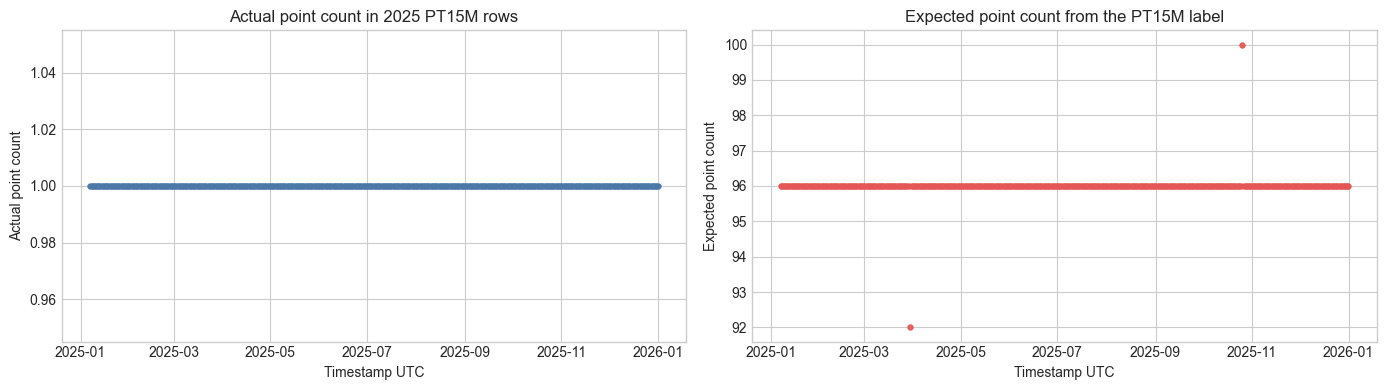

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(
    pt15m_rows["timestamp_utc"],
    pt15m_rows["point_count_in_period"],
    s=12,
    alpha=0.7,
    color="#4C78A8",
)
axes[0].set_title("Actual point count in 2025 PT15M rows")
axes[0].set_xlabel("Timestamp UTC")
axes[0].set_ylabel("Actual point count")

axes[1].scatter(
    pt15m_rows["timestamp_utc"],
    pt15m_rows["expected_point_count_from_reported_resolution"],
    s=12,
    alpha=0.7,
    color="#E45756",
)
axes[1].set_title("Expected point count from the PT15M label")
axes[1].set_xlabel("Timestamp UTC")
axes[1].set_ylabel("Expected point count")

plt.tight_layout()
plt.show()


## 7. Cleaning Step 1: Deduplicate Boundary Overlaps

The first cleaning action is small but necessary: some year-end periods appear in both the trailing page of one year and the first page of the next. We keep the latest record by creation time and source ordering.


In [14]:
deduped_native, duplicates_removed = cleaning.deduplicate_rows(raw_parsed)

print(f"Rows before deduplication: {len(raw_parsed):,}")
print(f"Rows after deduplication: {len(deduped_native):,}")
print(f"Duplicates removed: {len(duplicates_removed):,}")

display(
    deduped_native[
        [
            "timestamp_utc",
            "interval_end_utc",
            "flow_direction_label",
            "quantity_maw",
            "procurement_price_eur",
            "reported_resolution",
            "interval_interpretation",
        ]
    ].head(10)
)


Rows before deduplication: 2,930
Rows after deduplication: 2,924
Duplicates removed: 6


,timestamp_utc,interval_end_utc,flow_direction_label,quantity_maw,procurement_price_eur,reported_resolution,interval_interpretation
0,2021-12-31 23:00:00+00:00,2022-01-01 23:00:00+00:00,Up,915.0,4.71,P1D,single_point_full_period
1,2021-12-31 23:00:00+00:00,2022-01-01 23:00:00+00:00,Down,800.0,11.75,P1D,single_point_full_period
2,2022-01-01 23:00:00+00:00,2022-01-02 23:00:00+00:00,Up,995.0,3.62,P1D,single_point_full_period
3,2022-01-01 23:00:00+00:00,2022-01-02 23:00:00+00:00,Down,745.0,13.85,P1D,single_point_full_period
4,2022-01-02 23:00:00+00:00,2022-01-03 23:00:00+00:00,Up,995.0,3.17,P1D,single_point_full_period
5,2022-01-02 23:00:00+00:00,2022-01-03 23:00:00+00:00,Down,740.0,7.86,P1D,single_point_full_period
6,2022-01-03 23:00:00+00:00,2022-01-04 23:00:00+00:00,Up,995.0,2.83,P1D,single_point_full_period
7,2022-01-03 23:00:00+00:00,2022-01-04 23:00:00+00:00,Down,835.0,4.88,P1D,single_point_full_period
8,2022-01-04 23:00:00+00:00,2022-01-05 23:00:00+00:00,Up,795.0,2.46,P1D,single_point_full_period
9,2022-01-04 23:00:00+00:00,2022-01-05 23:00:00+00:00,Down,645.0,5.73,P1D,single_point_full_period


## 8. Cleaning Step 2: Expand Native Contract Periods to Hourly Rows

The native table is still a contract-period table. To join it later with hourly forecasting inputs, we expand every native interval into hourly rows while preserving the same contract value within the covered period.


In [15]:
hourly_long = cleaning.aggregate_hourly(deduped_native)
display(hourly_long.head(12))

hourly_stage_summary = cleaning.summarize_hourly(hourly_long)
display(hourly_stage_summary)


,family,market,timestamp_utc,interval_end_utc,quantity_maw,procurement_price_eur,source_observations,coverage_minutes,expected_coverage_minutes,quantity_valid_minutes,price_valid_minutes,is_complete_hour,source_file_count,flow_direction_code,flow_direction_label,contract_type_code,contract_type_label,reserve_source_code,reserve_source_label,price_category_code,price_category_label,target_delivery_local_date,target_hour_local,known_at_utc,known_at_rule
0,balancing_reserves_under_contract,NL,2021-12-31 23:00:00+00:00,2022-01-01 00:00:00+00:00,915.0,4.71,1,60,60,60,60,True,1,A01,Up,A01,Daily,A04,Local,A06,Average_bid_price,2022-01-01,0,NaT,allocation_decision_datetime_utc
1,balancing_reserves_under_contract,NL,2021-12-31 23:00:00+00:00,2022-01-01 00:00:00+00:00,800.0,11.75,1,60,60,60,60,True,1,A02,Down,A01,Daily,A04,Local,A06,Average_bid_price,2022-01-01,0,NaT,allocation_decision_datetime_utc
2,balancing_reserves_under_contract,NL,2022-01-01 00:00:00+00:00,2022-01-01 01:00:00+00:00,915.0,4.71,1,60,60,60,60,True,1,A01,Up,A01,Daily,A04,Local,A06,Average_bid_price,2022-01-01,1,NaT,allocation_decision_datetime_utc
3,balancing_reserves_under_contract,NL,2022-01-01 00:00:00+00:00,2022-01-01 01:00:00+00:00,800.0,11.75,1,60,60,60,60,True,1,A02,Down,A01,Daily,A04,Local,A06,Average_bid_price,2022-01-01,1,NaT,allocation_decision_datetime_utc
4,balancing_reserves_under_contract,NL,2022-01-01 01:00:00+00:00,2022-01-01 02:00:00+00:00,915.0,4.71,1,60,60,60,60,True,1,A01,Up,A01,Daily,A04,Local,A06,Average_bid_price,2022-01-01,2,NaT,allocation_decision_datetime_utc
5,balancing_reserves_under_contract,NL,2022-01-01 01:00:00+00:00,2022-01-01 02:00:00+00:00,800.0,11.75,1,60,60,60,60,True,1,A02,Down,A01,Daily,A04,Local,A06,Average_bid_price,2022-01-01,2,NaT,allocation_decision_datetime_utc
6,balancing_reserves_under_contract,NL,2022-01-01 02:00:00+00:00,2022-01-01 03:00:00+00:00,915.0,4.71,1,60,60,60,60,True,1,A01,Up,A01,Daily,A04,Local,A06,Average_bid_price,2022-01-01,3,NaT,allocation_decision_datetime_utc
7,balancing_reserves_under_contract,NL,2022-01-01 02:00:00+00:00,2022-01-01 03:00:00+00:00,800.0,11.75,1,60,60,60,60,True,1,A02,Down,A01,Daily,A04,Local,A06,Average_bid_price,2022-01-01,3,NaT,allocation_decision_datetime_utc
8,balancing_reserves_under_contract,NL,2022-01-01 03:00:00+00:00,2022-01-01 04:00:00+00:00,915.0,4.71,1,60,60,60,60,True,1,A01,Up,A01,Daily,A04,Local,A06,Average_bid_price,2022-01-01,4,NaT,allocation_decision_datetime_utc
9,balancing_reserves_under_contract,NL,2022-01-01 03:00:00+00:00,2022-01-01 04:00:00+00:00,800.0,11.75,1,60,60,60,60,True,1,A02,Down,A01,Daily,A04,Local,A06,Average_bid_price,2022-01-01,4,NaT,allocation_decision_datetime_utc


,flow_direction_code,flow_direction_label,rows,unique_hours,missing_quantity_rows,missing_price_rows,incomplete_hours,min_timestamp_utc,max_interval_end_utc,min_local_delivery_date,max_local_delivery_date
0,A01,Up,35088,35088,0,0,0,2021-12-31T23:00:00+00:00,2026-01-01T23:00:00+00:00,2022-01-01,2026-01-01
1,A02,Down,35088,35088,0,0,0,2021-12-31T23:00:00+00:00,2026-01-01T23:00:00+00:00,2022-01-01,2026-01-01


## 9. Cleaning Step 3: Build an Hourly Wide Table

The wide table is just a convenience layer for modelling and inspection. It keeps one UTC timestamp per row and exposes separate columns for up/down reserve quantities and procurement prices.


In [16]:
hourly_wide = cleaning.build_hourly_wide(hourly_long)
display(hourly_wide.head(12))


,timestamp_utc,nl_down_procurement_price_eur,nl_down_quantity_maw,nl_up_procurement_price_eur,nl_up_quantity_maw
0,2021-12-31 23:00:00+00:00,11.75,800.0,4.71,915.0
1,2022-01-01 00:00:00+00:00,11.75,800.0,4.71,915.0
2,2022-01-01 01:00:00+00:00,11.75,800.0,4.71,915.0
3,2022-01-01 02:00:00+00:00,11.75,800.0,4.71,915.0
4,2022-01-01 03:00:00+00:00,11.75,800.0,4.71,915.0
5,2022-01-01 04:00:00+00:00,11.75,800.0,4.71,915.0
6,2022-01-01 05:00:00+00:00,11.75,800.0,4.71,915.0
7,2022-01-01 06:00:00+00:00,11.75,800.0,4.71,915.0
8,2022-01-01 07:00:00+00:00,11.75,800.0,4.71,915.0
9,2022-01-01 08:00:00+00:00,11.75,800.0,4.71,915.0


## 10. Diagnostics on the Cleaned Hourly Outputs

Once the native intervals are expanded, the hourly outputs should be complete on the UTC grid and free of duplicate hours.


C:\Users\marijnvalk\AppData\Local\Temp\ipykernel_26916\2159614260.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hourly_long.assign(month=hourly_long["timestamp_utc"].dt.to_period("M").astype(str))


,month,flow_direction_label,mean_quantity_maw,mean_procurement_price_eur
0,2021-12,Down,800.000000,11.750000
1,2021-12,Up,915.000000,4.710000
2,2022-01,Down,700.208333,4.957944
3,2022-01,Up,982.076613,4.549731
4,2022-02,Down,790.349702,4.343557
5,2022-02,Up,952.604167,6.345446
6,2022-03,Down,816.283602,3.763602
7,2022-03,Up,773.924731,4.311129
8,2022-04,Down,758.305556,6.743972
9,2022-04,Up,857.611111,6.279722


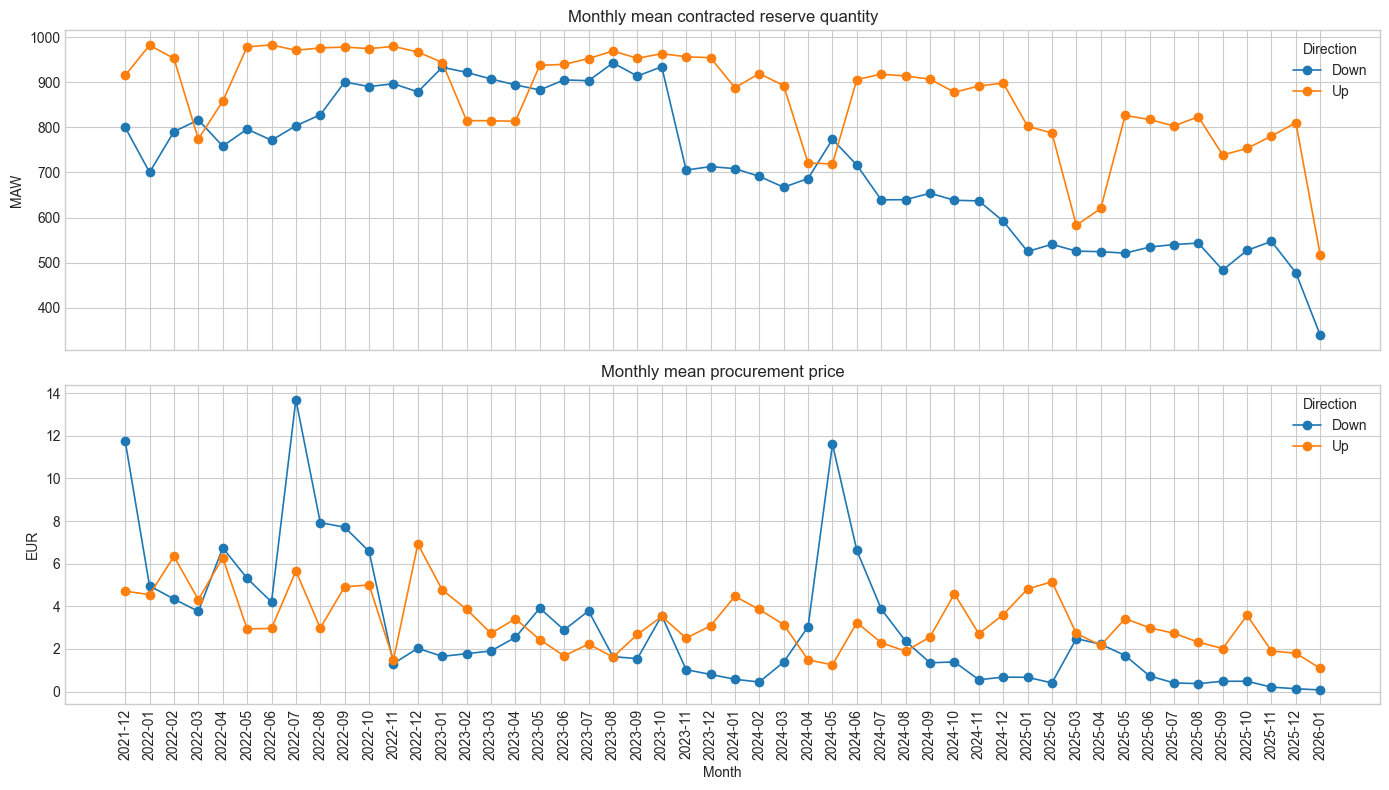

In [17]:
monthly_means = (
    hourly_long.assign(month=hourly_long["timestamp_utc"].dt.to_period("M").astype(str))
    .groupby(["month", "flow_direction_label"], as_index=False)
    .agg(
        mean_quantity_maw=("quantity_maw", "mean"),
        mean_procurement_price_eur=("procurement_price_eur", "mean"),
    )
)
display(monthly_means.head(12))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for direction, group in monthly_means.groupby("flow_direction_label"):
    axes[0].plot(group["month"], group["mean_quantity_maw"], marker="o", linewidth=1.2, label=direction)
    axes[1].plot(group["month"], group["mean_procurement_price_eur"], marker="o", linewidth=1.2, label=direction)

axes[0].set_title("Monthly mean contracted reserve quantity")
axes[0].set_ylabel("MAW")
axes[0].legend(title="Direction")

axes[1].set_title("Monthly mean procurement price")
axes[1].set_ylabel("EUR")
axes[1].set_xlabel("Month")
axes[1].legend(title="Direction")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


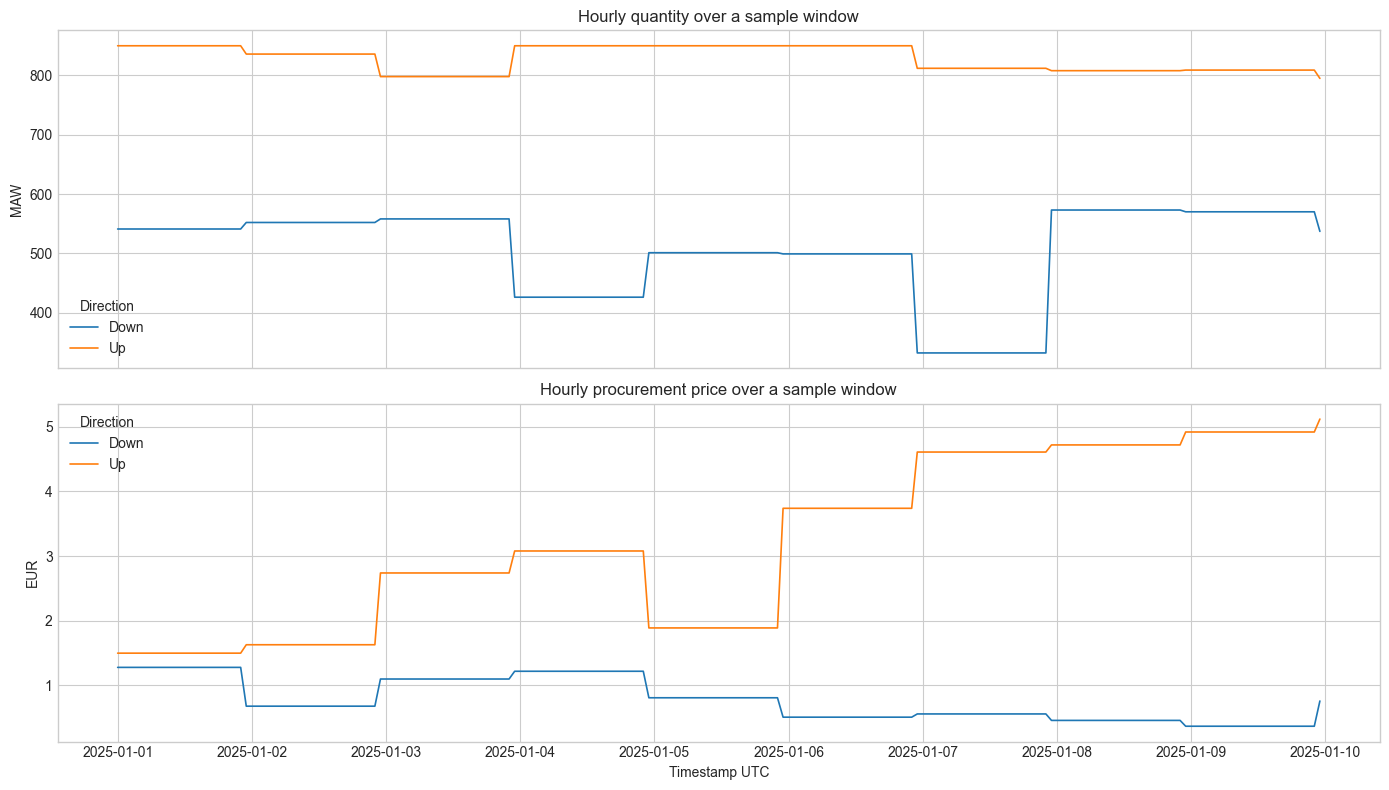

In [18]:
sample_start = pd.Timestamp("2025-01-01T00:00:00Z")
sample_end = pd.Timestamp("2025-01-10T00:00:00Z")
sample_hourly = hourly_long[
    (hourly_long["timestamp_utc"] >= sample_start) & (hourly_long["timestamp_utc"] < sample_end)
].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for direction, group in sample_hourly.groupby("flow_direction_label"):
    axes[0].plot(group["timestamp_utc"], group["quantity_maw"], linewidth=1.2, label=direction)
    axes[1].plot(group["timestamp_utc"], group["procurement_price_eur"], linewidth=1.2, label=direction)

axes[0].set_title("Hourly quantity over a sample window")
axes[0].set_ylabel("MAW")
axes[0].legend(title="Direction")

axes[1].set_title("Hourly procurement price over a sample window")
axes[1].set_ylabel("EUR")
axes[1].set_xlabel("Timestamp UTC")
axes[1].legend(title="Direction")

plt.tight_layout()
plt.show()


## 11. Saved Outputs and Diagnostics

The standalone cleaner saves the cleaned artifacts under `data/01_cleaned/Balancing/balancing_reserves_under_contract`.


In [19]:
artifact_df = pd.DataFrame(
    [
        {"artifact": "Parsed long", "path": str(PARSED_OUTPUT), "exists": PARSED_OUTPUT.exists()},
        {"artifact": "Hourly long", "path": str(HOURLY_LONG_OUTPUT), "exists": HOURLY_LONG_OUTPUT.exists()},
        {"artifact": "Hourly wide", "path": str(HOURLY_WIDE_OUTPUT), "exists": HOURLY_WIDE_OUTPUT.exists()},
        {"artifact": "Diagnostics directory", "path": str(DIAGNOSTICS_DIR), "exists": DIAGNOSTICS_DIR.exists()},
    ]
)
display(artifact_df)


,artifact,path,exists
0,Parsed long,C:\Users\marijnvalk\PycharmProjects\Thesis\data\01_cleaned\Balancing\balancing_reserves_under_contract\parsed\balancing_reserves_under_contract_long.csv,True
1,Hourly long,C:\Users\marijnvalk\PycharmProjects\Thesis\data\01_cleaned\Balancing\balancing_reserves_under_contract\hourly\balancing_reserves_under_contract_hourly_long.csv,True
2,Hourly wide,C:\Users\marijnvalk\PycharmProjects\Thesis\data\01_cleaned\Balancing\balancing_reserves_under_contract\hourly\balancing_reserves_under_contract_hourly_wide.csv,True
3,Diagnostics directory,C:\Users\marijnvalk\PycharmProjects\Thesis\data\01_cleaned\Balancing\balancing_reserves_under_contract\diagnostics,True


## 12. What To Take Away

The diagnostics support the following interpretation:

- this is a **contracted reserve** dataset, not an activated-energy dataset
- the native observation level is effectively **one full contract period per direction**
- the contract periods are daily in practice, with local-DST effects causing 23/24/25-hour UTC spans
- year-end archive paging introduces a few duplicate overlaps, which should be removed upstream
- the 2025 `PT15M` label is not enough to justify quarter-hourly modelling because the payload still contains only one full-period point per direction

So the cleaned hourly outputs are best understood as an hourly convenience expansion of daily contract data, not as truly native hourly or quarter-hourly reserve procurement observations.
